In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"]=os.getenv("GEMINI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [2]:
from typing import Literal


### Tools- Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)

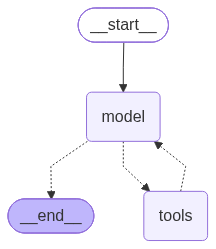

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=os.environ["GEMINI_API_KEY"],
)

## Basic Agent
from langchain.agents import create_agent


simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

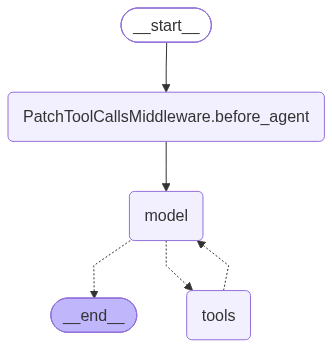

In [4]:
### Create a deep agent
## Prompt

## agent

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [5]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='f7837e3e-ef42-4630-94aa-3dcc0c648237'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "deepagent"}'}, '__gemini_function_call_thought_signatures__': {'call_890483': 'ErUECrIEARFNMg9O89m4UoBw1M6iOc8Qr7C2RMjrYbgoZjeUt6Y60xXtENd3hX43EUrT1brdHwAjyN1nzNRLIa2uSObh9WiOvtxeoUT5R/+SXMTWbQG1Nl4y/0YooOj5mAi5sr2PRBl8/yRF+6d5MWoLfXIGlYyY9qD3RvhmU59PqhhZbmeHwycYB5mKRf+o+Cyj0HtUJU72J0+BmAMrel0/D8n+9YNH65g8PJoj/r+gW94XQdXFuawp452HsEUJWtUUPfAo+qnazh+4SdD5C5N2KZJoO1XWcYpRJlBqYvRvjKT+NuYACJNvFYe9VsBjJMrx9CgrcuEYO0AuBQxf3AssXBbWppnq0TyMjEqe2+rWCmA2BgU/U4ygr7WaBvktbwk7m54HWSYvgXQE/AgrovGHJgcdxyityy0BSdJurK1z8Ymn3Qnjmd5F32+HF86T2WjQesQzW47yc4L54GC/3Z3wL7OnUE35iUFetc7D1xsksrE4VkuZWDJO+wdn3NuQSnXuHGdaoKfhDnvs2Mq+4FOtWg1Gj0Htz1Y9X8uAzVcB38cDZ9G0ZIhkxCS11tbqdBFEqkh+34ZRg5FnzlGLuNvG1cV8ZvcG7la3Xen7q9e+qR5RkO9afqJqerSoOWJUkPAsnVZ6yyleWjNlV9ziuawA5v3x

## customize deep agents

In [ ]:
## #Model
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model   
from deepagents import create_deep_agent

model = init_chat_model("google_genai:gemini-3.6-flash")
agent = create_deep_agent(model=model)
agent


result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

In [ ]:
from deepagents import create_deep_agent

research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='566ad50e-4584-4000-b28d-1f5ab828da66'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'glob', 'arguments': '{"pattern": "*"}'}, '__gemini_function_call_thought_signatures__': {'call_805085': 'EpMDCpADARFNMg8Xq75+SW8PYB0orXuTu5lWzhfH01aDqusdL7pCKO+3WiPRuxryi0NSjEd/6XFynCcwW2f/IKISvWKZd6nrxayhNe0YDoAHp6lLSM+1r9CDKvhSUon+Rxj0iZc/yKrypLohLsunIQwI7o433GXF/lefZgXEUlqMw0iOCLuGq1YkDgemZO3J1Q0+wTBfNvO5QKm2L972bXErMfiLjSYbfWhrR6D29+3rD4LcXf5ukXT0nUxeA48RMhDvsRUIuGVt+pwO1Hk85G1hGMQUuAR7CVUl7yEJJxW4AXUt7C/RAJsr9CP8BxHez4Vgd89vRRgrV0BDCd6qQBOslmq7Zapdd/Z7qsMjK1/zyKbTh4cboRO/iWnIJUcRt0jrGo1gcIHN8HWF2cilOrRLxIML9pKl1ie8A6IJ+6eqrzBscvthZrd0gSYi2K+LwOInhKg655R2VKGvOt8VXPBtRmepfiXHhHIP6W97rqodmo+el1lun2uW4vQWG6iHM8JwuklWX4LA7k2/cOwPViDhi9MVug=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai

In [ ]:
### Tools
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

agent = create_deep_agent(
    model=model,
    tools=[internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent in Agentic AI?"}]})
result